In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")
print("PyTorch:", torch.__version__)

All libraries loaded!
PyTorch: 2.12.1+cpu


In [2]:
# Load multiple MIT-BIH records for better generalization

# These are the most commonly used records in research
records = ['100', '101', '103', '105', '106', '108', '109', '111', '112', '113']

def extract_beats_multirecord(record_ids, window_size=180):
    """
    Extract beats from multiple MIT-BIH records.
    Uses 5 beat types: N, A, V, L, R
    """
    all_beats = []
    all_labels = []
    
    # Valid beat types for arrhythmia classification
    valid_symbols = {
        'N': 0,  # Normal
        'A': 1,  # Atrial premature beat
        'V': 2,  # Premature ventricular contraction
        'L': 3,  # Left bundle branch block
        'R': 4,  # Right bundle branch block
    }
    
    for rec_id in record_ids:
        try:
            record = wfdb.rdrecord(rec_id, pn_dir='mitdb')
            annotation = wfdb.rdann(rec_id, 'atr', pn_dir='mitdb')
            ecg_signal = record.p_signal[:, 0]
            
            for i, sample in enumerate(annotation.sample):
                symbol = annotation.symbol[i]
                if symbol not in valid_symbols:
                    continue
                start = sample - window_size // 2
                end = sample + window_size // 2
                if start < 0 or end > len(ecg_signal):
                    continue
                beat = ecg_signal[start:end]
                # Normalize each beat
                min_val, max_val = beat.min(), beat.max()
                if max_val - min_val != 0:
                    beat = (beat - min_val) / (max_val - min_val)
                all_beats.append(beat)
                all_labels.append(valid_symbols[symbol])
            
            print(f"✓ Record {rec_id} loaded")
        except Exception as e:
            print(f"✗ Record {rec_id} failed: {e}")
    
    return np.array(all_beats), np.array(all_labels)

print("Loading MIT-BIH records...")
beats, labels = extract_beats_multirecord(records)

print(f"\nTotal beats: {len(beats)}")
print(f"Beat shape: {beats.shape}")
print("\nBeat type distribution:")
type_names = {0:'Normal', 1:'Atrial', 2:'Ventricular', 3:'Left BB', 4:'Right BB'}
for label, count in sorted(Counter(labels).items()):
    print(f"  {type_names[label]}: {count}")

Loading MIT-BIH records...
✓ Record 100 loaded
✓ Record 101 loaded
✓ Record 103 loaded
✓ Record 105 loaded
✓ Record 106 loaded
✓ Record 108 loaded
✓ Record 109 loaded
✓ Record 111 loaded
✓ Record 112 loaded
✓ Record 113 loaded

Total beats: 21550
Beat shape: (21550, 180)

Beat type distribution:
  Normal: 16274
  Atrial: 44
  Ventricular: 618
  Left BB: 4614


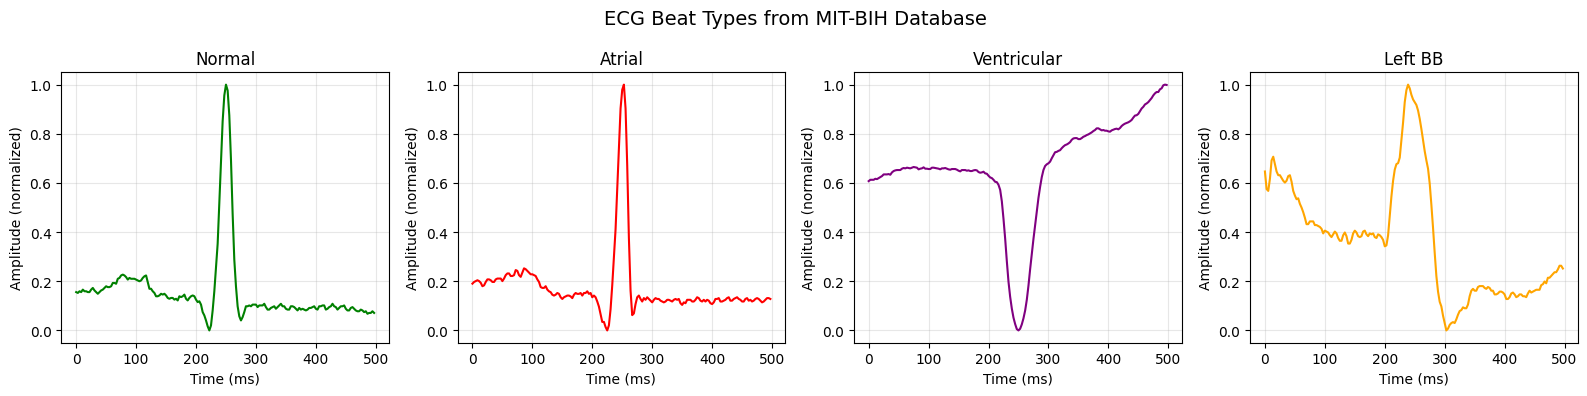

Minimum class count: 44

Balanced dataset:
Total beats: 176
  Normal: 44
  Atrial: 44
  Ventricular: 44
  Left BB: 44


In [3]:
# Visualize one beat of each type
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('ECG Beat Types from MIT-BIH Database', fontsize=14)

type_names = {0:'Normal', 1:'Atrial', 2:'Ventricular', 3:'Left BB'}
colors = {0:'green', 1:'red', 2:'purple', 3:'orange'}
time_ms = np.arange(180) / 360 * 1000

for label in range(4):
    idx = np.where(labels == label)[0][0]
    axes[label].plot(time_ms, beats[idx], 
                    color=colors[label], linewidth=1.5)
    axes[label].set_title(type_names[label])
    axes[label].set_xlabel('Time (ms)')
    axes[label].set_ylabel('Amplitude (normalized)')
    axes[label].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Handle class imbalance — undersample majority class
from sklearn.utils import resample

# Find minimum class count
min_count = min(Counter(labels).values())
print(f"Minimum class count: {min_count}")

# Undersample each class to balance
balanced_beats = []
balanced_labels = []

for label in range(4):
    idx = np.where(labels == label)[0]
    beats_class = beats[idx]
    labels_class = labels[idx]
    
    if len(beats_class) > min_count:
        beats_class, labels_class = resample(
            beats_class, labels_class,
            n_samples=min_count,
            random_state=42
        )
    
    balanced_beats.append(beats_class)
    balanced_labels.append(labels_class)

X = np.vstack(balanced_beats)
y = np.hstack(balanced_labels)

print(f"\nBalanced dataset:")
print(f"Total beats: {len(X)}")
for label in range(4):
    print(f"  {type_names[label]}: {np.sum(y == label)}")

In [4]:
# Better approach — oversample minority classes to 500 each
from sklearn.utils import resample

target_count = 500

balanced_beats = []
balanced_labels = []

for label in range(4):
    idx = np.where(labels == label)[0]
    beats_class = beats[idx]
    labels_class = labels[idx]
    
    if len(beats_class) < target_count:
        # Oversample minority class
        beats_class, labels_class = resample(
            beats_class, labels_class,
            n_samples=target_count,
            replace=True,
            random_state=42
        )
    else:
        # Undersample majority class
        beats_class, labels_class = resample(
            beats_class, labels_class,
            n_samples=target_count,
            replace=False,
            random_state=42
        )
    
    balanced_beats.append(beats_class)
    balanced_labels.append(labels_class)

X = np.vstack(balanced_beats)
y = np.hstack(balanced_labels)

print(f"Balanced dataset:")
print(f"Total beats: {len(X)}")
for label in range(4):
    print(f"  {type_names[label]}: {np.sum(y == label)}")

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Convert to PyTorch tensors — reshape for 1D CNN
# CNN expects (batch, channels, length)
X_train_tensor = torch.FloatTensor(X_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test).unsqueeze(1)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

print(f"\nTensor shapes:")
print(f"X_train: {X_train_tensor.shape}")
print(f"X_test: {X_test_tensor.shape}")

Balanced dataset:
Total beats: 2000
  Normal: 500
  Atrial: 500
  Ventricular: 500
  Left BB: 500

Training samples: 1600
Testing samples: 400

Tensor shapes:
X_train: torch.Size([1600, 1, 180])
X_test: torch.Size([400, 1, 180])


In [5]:
# Build 1D CNN for ECG classification

class ECG_CNN(nn.Module):
    def __init__(self, num_classes=4):
        super(ECG_CNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        
        # Pooling and normalization
        self.pool = nn.MaxPool1d(2)
        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)
        
        # Activation and regularization
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 22, 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)
    
    def forward(self, x):
        # Conv block 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        
        # Conv block 2
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        
        # Conv block 3
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return x

# Create model
model = ECG_CNN(num_classes=4)
print(model)
print("\nTotal parameters:", sum(p.numel() for p in model.parameters()))

# Test with dummy input
dummy = torch.randn(1, 1, 180)
output = model(dummy)
print("Output shape:", output.shape)

ECG_CNN(
  (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2816, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=4, bias=True)
)

Total parameters: 773508
Output shape: torch.Size([1, 4])


In [6]:
# Train the 1D CNN

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

epochs = 50
train_losses = []
test_losses = []
train_accs = []
test_accs = []

for epoch in range(epochs):
    # Training
    model.train()
    y_pred = model(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    train_acc = accuracy_score(
        y_train_tensor.numpy(),
        y_pred.argmax(dim=1).detach().numpy()
    )
    train_losses.append(loss.item())
    train_accs.append(train_acc)
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        y_test_pred = model(X_test_tensor)
        test_loss = criterion(y_test_pred, y_test_tensor)
        test_acc = accuracy_score(
            y_test_tensor.numpy(),
            y_test_pred.argmax(dim=1).numpy()
        )
    test_losses.append(test_loss.item())
    test_accs.append(test_acc)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | "
              f"Train Loss: {loss.item():.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Test Acc: {test_acc:.4f}")

print("\nTraining complete!")


Epoch 10/50 | Train Loss: 0.3465 | Train Acc: 0.8650 | Test Acc: 0.3275
Epoch 20/50 | Train Loss: 0.1529 | Train Acc: 0.9437 | Test Acc: 0.6225
Epoch 30/50 | Train Loss: 0.0727 | Train Acc: 0.9812 | Test Acc: 0.8575
Epoch 40/50 | Train Loss: 0.0392 | Train Acc: 0.9912 | Test Acc: 0.9475
Epoch 50/50 | Train Loss: 0.0288 | Train Acc: 0.9919 | Test Acc: 0.9750

Training complete!


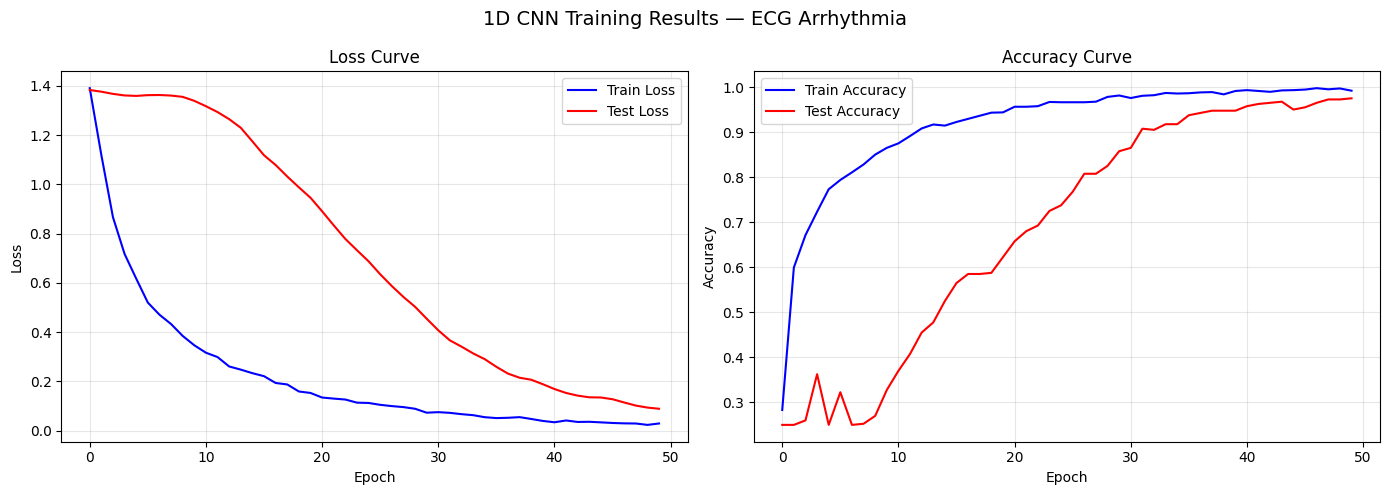

Final Test Accuracy : 0.9750
Final F1 Score      : 0.9750

Detailed Report:
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       100
      Atrial       0.99      0.97      0.98       100
 Ventricular       1.00      0.95      0.97       100
     Left BB       0.97      1.00      0.99       100

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.98       400
weighted avg       0.98      0.97      0.98       400



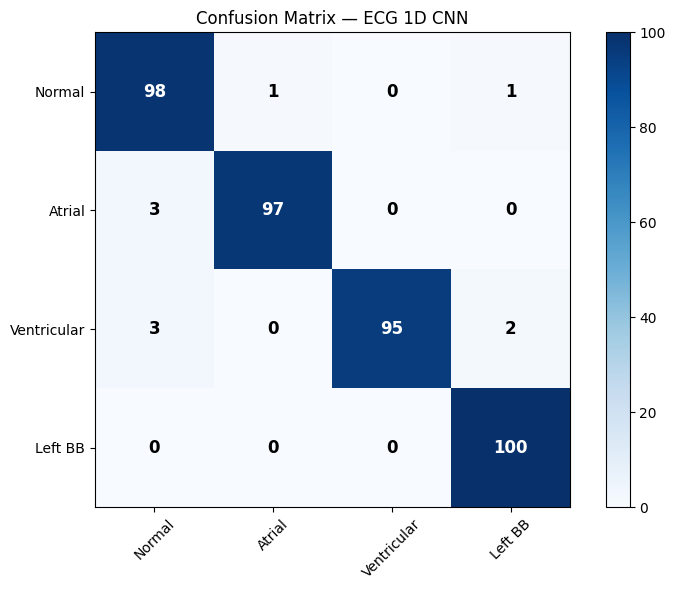

In [7]:
# Evaluate and plot results

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('1D CNN Training Results — ECG Arrhythmia', fontsize=14)

axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(test_losses, label='Test Loss', color='red')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Accuracy', color='blue')
axes[1].plot(test_accs, label='Test Accuracy', color='red')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final evaluation
model.eval()
with torch.no_grad():
    y_pred_final = model(X_test_tensor)
    y_pred_classes = y_pred_final.argmax(dim=1).numpy()

acc = accuracy_score(y_test_tensor.numpy(), y_pred_classes)
f1 = f1_score(y_test_tensor.numpy(), y_pred_classes, average='weighted')

print(f"Final Test Accuracy : {acc:.4f}")
print(f"Final F1 Score      : {f1:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test_tensor.numpy(), y_pred_classes,
      target_names=['Normal', 'Atrial', 'Ventricular', 'Left BB']))

# Confusion matrix
cm = confusion_matrix(y_test_tensor.numpy(), y_pred_classes)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix — ECG 1D CNN')
plt.colorbar()
plt.xticks(range(4), ['Normal', 'Atrial', 'Ventricular', 'Left BB'], rotation=45)
plt.yticks(range(4), ['Normal', 'Atrial', 'Ventricular', 'Left BB'])
for i in range(4):
    for j in range(4):
        plt.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black',
                fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()